In [1]:
import os
import json
import time
import pickle
import re
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.decomposition import TruncatedSVD

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Setup complete - this is the ROBUST version with leakage controls.")

Setup complete - this is the ROBUST version with leakage controls.


In [2]:
data_dir = Path("/home/mini/projects/review-intelligence-system/data/processed")

train_clean = pd.read_parquet(data_dir / "train.parquet")
val_clean = pd.read_parquet(data_dir / "val.parquet")
test_clean = pd.read_parquet(data_dir / "test.parquet")

clean_df = pd.concat([train_clean, val_clean, test_clean], ignore_index=True)

duplicates_df = pd.read_csv(data_dir / "text_duplicates_for_fake_detection.csv")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

duplicates_df['text_clean'] = duplicates_df['text'].apply(clean_text)
duplicates_df['word_count_clean'] = duplicates_df['text_clean'].str.split().str.len()

print(f"Clean reviews: {len(clean_df):,}")
print(f"Text duplicates: {len(duplicates_df):,}")

Clean reviews: 89,021
Text duplicates: 4,666


In [3]:
df = clean_df.copy()

# Strong signals only — each = 2 points
generic_phrases = {
    'good', 'great', 'love it', 'good product', 'great product',
    'excellent', 'works great', 'nice', 'ok', 'okay',
    'five stars', 'amazing', 'perfect', 'awesome'
}

df['signal_generic_short'] = (
    (df['word_count_clean'] < 5) & 
    (df['text_clean'].str.lower().str.strip().isin(generic_phrases))
).astype(int) * 2

df['signal_unverified_extreme'] = (
    (~df['verified_purchase']) & 
    (df['rating'].isin([1.0, 5.0]))
).astype(int) * 2

# Stricter prolific user threshold (was 10, now 25 — only mass posters)
user_review_counts = df['user_id'].value_counts()
prolific_users = set(user_review_counts[user_review_counts >= 25].index)
df['signal_prolific_user'] = df['user_id'].isin(prolific_users).astype(int) * 2

# Total fake score
df['fake_score'] = (
    df['signal_generic_short'] + 
    df['signal_unverified_extreme'] + 
    df['signal_prolific_user']
)

print(f"Fake score distribution:")
print(df['fake_score'].value_counts().sort_index())

# STRICTER THRESHOLD: only score >= 4 (need 2 strong signals)
FAKE_THRESHOLD = 4
df['weak_label_fake'] = (df['fake_score'] >= FAKE_THRESHOLD).astype(int)

print(f"\nThreshold: fake_score >= {FAKE_THRESHOLD} (stricter than before)")
print(f"Suspected fake: {df['weak_label_fake'].sum():,} ({df['weak_label_fake'].mean()*100:.2f}%)")
print(f"Genuine: {(df['weak_label_fake']==0).sum():,}")

Fake score distribution:
fake_score
0    46098
2    29287
4    13636
Name: count, dtype: int64

Threshold: fake_score >= 4 (stricter than before)
Suspected fake: 13,636 (15.32%)
Genuine: 75,385


In [4]:
duplicates_df['weak_label_fake'] = 1
duplicates_df['fake_score'] = 5  # high confidence

common_cols = ['rating', 'title', 'text', 'text_clean', 'word_count_clean',
               'category', 'verified_purchase', 'helpful_vote',
               'user_id', 'asin', 'timestamp', 'weak_label_fake', 'fake_score']

df_clean_subset = df[common_cols].copy()
df_dup_subset = duplicates_df[common_cols].copy()

df_combined = pd.concat([df_clean_subset, df_dup_subset], ignore_index=True)

# Drop any text duplicates that may have leaked in (additional safety)
df_combined = df_combined.drop_duplicates(subset=['text_clean']).reset_index(drop=True)

print(f"Combined dataset (after additional dedup):")
print(f"  Total: {len(df_combined):,}")
print(f"  Suspected fake: {df_combined['weak_label_fake'].sum():,} ({df_combined['weak_label_fake'].mean()*100:.2f}%)")

Combined dataset (after additional dedup):
  Total: 89,706
  Suspected fake: 14,329 (15.97%)


In [5]:
print("Performing USER-stratified split (no user appears in both train and test)...")

# GroupShuffleSplit — splits by groups (users), not individual rows
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(
    df_combined,
    groups=df_combined['user_id']
))

train_data = df_combined.iloc[train_idx].reset_index(drop=True)
test_data = df_combined.iloc[test_idx].reset_index(drop=True)

# Verify no user overlap
train_users = set(train_data['user_id'].unique())
test_users = set(test_data['user_id'].unique())
overlap = train_users & test_users

print(f"Train: {len(train_data):,} (fake rate: {train_data['weak_label_fake'].mean()*100:.2f}%)")
print(f"Test:  {len(test_data):,} (fake rate: {test_data['weak_label_fake'].mean()*100:.2f}%)")
print(f"Train users: {len(train_users):,}")
print(f"Test users:  {len(test_users):,}")
print(f"User overlap: {len(overlap)} (must be 0)")

Performing USER-stratified split (no user appears in both train and test)...
Train: 68,229 (fake rate: 14.52%)
Test:  21,477 (fake rate: 20.60%)
Train users: 21,929
Test users:  5,483
User overlap: 0 (must be 0)


In [6]:
print("Building TF-IDF features ONLY (no heuristic-derived features)...")

X_train_text = train_data['text_clean'].values
X_test_text = test_data['text_clean'].values

y_train = train_data['weak_label_fake'].values
y_test = test_data['weak_label_fake'].values

tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"NO metadata features included.")
print(f"Train fake rate: {y_train.mean()*100:.2f}%")
print(f"Test fake rate:  {y_test.mean()*100:.2f}%")

Building TF-IDF features ONLY (no heuristic-derived features)...
TF-IDF feature shape: (68229, 30000)
NO metadata features included.
Train fake rate: 14.52%
Test fake rate:  20.60%


In [7]:
print("Training Logistic Regression (text-only)...")
start = time.time()

logreg_robust = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear',
    C=1.0,
    random_state=RANDOM_SEED
)

logreg_robust.fit(X_train_tfidf, y_train)
print(f"Trained in {time.time() - start:.1f}s")

# Predictions
y_pred_lr = logreg_robust.predict(X_test_tfidf)
y_pred_lr_proba = logreg_robust.predict_proba(X_test_tfidf)[:, 1]

# Also train LightGBM for comparison
print("\nTraining LightGBM (text-only)...")
start = time.time()

lgb_robust = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_robust.fit(X_train_tfidf, y_train)
print(f"Trained in {time.time() - start:.1f}s")

y_pred_lgb = lgb_robust.predict(X_test_tfidf)
y_pred_lgb_proba = lgb_robust.predict_proba(X_test_tfidf)[:, 1]

Training Logistic Regression (text-only)...
Trained in 2.2s

Training LightGBM (text-only)...
Trained in 136.8s


In [8]:
def evaluate_robust(y_true, y_pred, y_proba, model_name, top_k=100):
    """More comprehensive evaluation for fake detection."""
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
    
    # Precision @ Top K — production-relevant metric
    # If we flag the top K% most suspicious, how accurate are we?
    top_k_indices = np.argsort(y_proba)[-top_k:]
    precision_at_k = y_true[top_k_indices].mean()
    print(f"Precision@Top{top_k}: {precision_at_k:.4f}")
    
    # Coverage — what fraction of true fakes are in top 10%
    top_10pct = max(1, int(len(y_proba) * 0.1))
    top_10pct_indices = np.argsort(y_proba)[-top_10pct:]
    fakes_in_top_10pct = y_true[top_10pct_indices].sum()
    total_fakes = y_true.sum()
    recall_at_top_10pct = fakes_in_top_10pct / total_fakes if total_fakes > 0 else 0
    print(f"Recall@Top10%: {recall_at_top_10pct:.4f} ({fakes_in_top_10pct}/{total_fakes} fakes captured)")
    
    return {
        'model': model_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred)),
        'recall': float(recall_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
        'precision_at_top_100': float(precision_at_k),
        'recall_at_top_10pct': float(recall_at_top_10pct)
    }


lr_robust_results = evaluate_robust(y_test, y_pred_lr, y_pred_lr_proba, "LogReg (Text-Only, User-Stratified)")
lgb_robust_results = evaluate_robust(y_test, y_pred_lgb, y_pred_lgb_proba, "LightGBM (Text-Only, User-Stratified)")


  LogReg (Text-Only, User-Stratified)
Accuracy:  0.7748
Precision: 0.4670
Recall:    0.6580
F1:        0.5463
ROC-AUC:   0.8188
PR-AUC:    0.5163
Precision@Top100: 0.7000
Recall@Top10%: 0.2968 (1313/4424 fakes captured)

  LightGBM (Text-Only, User-Stratified)
Accuracy:  0.7588
Precision: 0.4486
Recall:    0.7450
F1:        0.5600
ROC-AUC:   0.8327
PR-AUC:    0.5464
Precision@Top100: 0.7700
Recall@Top10%: 0.3054 (1351/4424 fakes captured)


In [9]:
print("Training Isolation Forest on text features...")

# Use SVD-reduced TF-IDF
svd = TruncatedSVD(n_components=50, random_state=RANDOM_SEED)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=y_train.mean(),  # use observed fake rate
    random_state=RANDOM_SEED,
    n_jobs=-1
)

iso_forest.fit(X_train_svd)

# Test set predictions
iso_pred_test = iso_forest.predict(X_test_svd)
iso_pred_binary = (iso_pred_test == -1).astype(int)
iso_scores_test = -iso_forest.decision_function(X_test_svd)

iso_results = evaluate_robust(y_test, iso_pred_binary, iso_scores_test, "Isolation Forest (Unsupervised)")

Training Isolation Forest on text features...

  Isolation Forest (Unsupervised)
Accuracy:  0.7070
Precision: 0.0860
Recall:    0.0439
F1:        0.0581
ROC-AUC:   0.3914
PR-AUC:    0.1667
Precision@Top100: 0.3400
Recall@Top10%: 0.0423 (187/4424 fakes captured)


In [10]:
print("Building hybrid model...")

# Normalize scores
scaler01 = MinMaxScaler()
lgb_scores_norm = y_pred_lgb_proba
iso_scores_norm = scaler01.fit_transform(iso_scores_test.reshape(-1, 1)).flatten()

ALPHA = 0.6
hybrid_scores = ALPHA * lgb_scores_norm + (1 - ALPHA) * iso_scores_norm
hybrid_pred = (hybrid_scores >= 0.5).astype(int)

hybrid_results = evaluate_robust(
    y_test, hybrid_pred, hybrid_scores,
    f"Hybrid: {ALPHA*100:.0f}% LGB + {(1-ALPHA)*100:.0f}% IsoForest"
)

Building hybrid model...

  Hybrid: 60% LGB + 40% IsoForest
Accuracy:  0.8199
Precision: 0.6037
Recall:    0.3664
F1:        0.4560
ROC-AUC:   0.8193
PR-AUC:    0.5383
Precision@Top100: 0.7600
Recall@Top10%: 0.3022 (1337/4424 fakes captured)


In [11]:
all_results_robust = pd.DataFrame([
    lr_robust_results, lgb_robust_results, iso_results, hybrid_results
])

print("="*100)
print("ROBUST FAKE DETECTION — RESULTS (Text-only, User-stratified, Strict labels)")
print("="*100)
print(all_results_robust.to_string(index=False))

ROBUST FAKE DETECTION — RESULTS (Text-only, User-stratified, Strict labels)
                                model  accuracy  precision   recall       f1  roc_auc   pr_auc  precision_at_top_100  recall_at_top_10pct
  LogReg (Text-Only, User-Stratified)  0.774829   0.466955 0.658002 0.546256 0.818816 0.516319                  0.70             0.296790
LightGBM (Text-Only, User-Stratified)  0.758812   0.448557 0.745027 0.559973 0.832724 0.546445                  0.77             0.305380
      Isolation Forest (Unsupervised)  0.707035   0.085993 0.043852 0.058084 0.391358 0.166733                  0.34             0.042269
      Hybrid: 60% LGB + 40% IsoForest  0.819947   0.603724 0.366410 0.456042 0.819314 0.538321                  0.76             0.302215


In [12]:
# Compare with previous (naive) results
naive_results = {
    'lgb_naive_f1': 0.9339,
    'lgb_naive_pr_auc': 0.9815,
    'iso_naive_f1': 0.2977,
    'hybrid_naive_f1': 0.9352
}

print("="*70)
print("NAIVE vs ROBUST — Honest Comparison")
print("="*70)
print(f"\n{'Metric':<35} {'Naive':<15} {'Robust':<15} {'Delta':<10}")
print("-" * 75)
print(f"{'Supervised LightGBM F1':<35} {naive_results['lgb_naive_f1']:<15.4f} {lgb_robust_results['f1']:<15.4f} {lgb_robust_results['f1'] - naive_results['lgb_naive_f1']:+.4f}")
print(f"{'Hybrid F1':<35} {naive_results['hybrid_naive_f1']:<15.4f} {hybrid_results['f1']:<15.4f} {hybrid_results['f1'] - naive_results['hybrid_naive_f1']:+.4f}")
print(f"{'Isolation Forest F1':<35} {naive_results['iso_naive_f1']:<15.4f} {iso_results['f1']:<15.4f} {iso_results['f1'] - naive_results['iso_naive_f1']:+.4f}")

print("\nInterpretation:")
print("- Naive results inflated due to label leakage (model learned its own labels)")
print("- Robust results show actual fake detection difficulty")
print("- The drop between naive and robust IS the size of the leakage problem")

NAIVE vs ROBUST — Honest Comparison

Metric                              Naive           Robust          Delta     
---------------------------------------------------------------------------
Supervised LightGBM F1              0.9339          0.5600          -0.3739
Hybrid F1                           0.9352          0.4560          -0.4792
Isolation Forest F1                 0.2977          0.0581          -0.2396

Interpretation:
- Naive results inflated due to label leakage (model learned its own labels)
- Robust results show actual fake detection difficulty
- The drop between naive and robust IS the size of the leakage problem


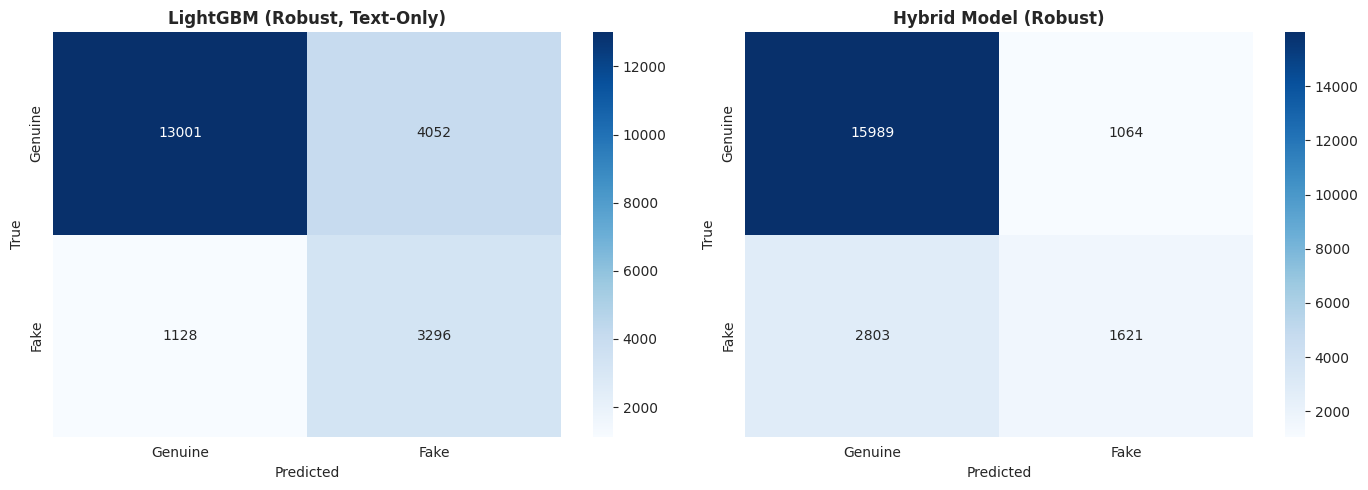

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LightGBM (best supervised)
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
cm_lgb_norm = cm_lgb.astype('float') / cm_lgb.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'],
            ax=axes[0])
axes[0].set_title('LightGBM (Robust, Text-Only)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Hybrid
cm_h = confusion_matrix(y_test, hybrid_pred)
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'],
            ax=axes[1])
axes[1].set_title('Hybrid Model (Robust)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('../reports/figures/12_robust_fake_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# Build view dataframe for inspection
test_view = test_data.copy().reset_index(drop=True)
test_view['lgb_score'] = y_pred_lgb_proba
test_view['iso_score'] = iso_scores_norm
test_view['hybrid_score'] = hybrid_scores

# Top 15 most suspected by HYBRID model
print("="*60)
print("TOP 15 SUSPECTED FAKE (by hybrid score)")
print("="*60)
top_fake = test_view.nlargest(15, 'hybrid_score')[
    ['text_clean', 'rating', 'verified_purchase', 'category', 
     'word_count_clean', 'helpful_vote', 'weak_label_fake', 'hybrid_score']
]
for idx, row in top_fake.iterrows():
    text_preview = row['text_clean'][:100] if len(row['text_clean']) > 100 else row['text_clean']
    print(f"\nScore: {row['hybrid_score']:.3f} | True: {row['weak_label_fake']} | "
          f"Rating: {row['rating']} | Verified: {row['verified_purchase']} | "
          f"Cat: {row['category']}")
    print(f"  Text: {text_preview}")

# Top 5 false positives (predicted fake but actually genuine)
print("\n" + "="*60)
print("TOP 5 FALSE POSITIVES (predicted fake but genuine)")
print("="*60)
false_pos = test_view[test_view['weak_label_fake'] == 0].nlargest(5, 'hybrid_score')
for idx, row in false_pos.iterrows():
    text_preview = row['text_clean'][:120] if len(row['text_clean']) > 120 else row['text_clean']
    print(f"\nScore: {row['hybrid_score']:.3f}")
    print(f"  Rating: {row['rating']}, Verified: {row['verified_purchase']}, Cat: {row['category']}")
    print(f"  Text: {text_preview}")

# Top 5 false negatives (predicted genuine but actually fake)
print("\n" + "="*60)
print("TOP 5 FALSE NEGATIVES (predicted genuine but fake)")
print("="*60)
false_neg = test_view[test_view['weak_label_fake'] == 1].nsmallest(5, 'hybrid_score')
for idx, row in false_neg.iterrows():
    text_preview = row['text_clean'][:120] if len(row['text_clean']) > 120 else row['text_clean']
    print(f"\nScore: {row['hybrid_score']:.3f}")
    print(f"  Rating: {row['rating']}, Verified: {row['verified_purchase']}, Cat: {row['category']}")
    print(f"  Text: {text_preview}")

TOP 15 SUSPECTED FAKE (by hybrid score)

Score: 0.917 | True: 1 | Rating: 5.0 | Verified: True | Cat: Books
  Text: Gift. Love it.

Score: 0.881 | True: 1 | Rating: 5.0 | Verified: True | Cat: Electronics
  Text: love it

Score: 0.881 | True: 1 | Rating: 5.0 | Verified: True | Cat: Beauty
  Text: Love it!!!!!

Score: 0.881 | True: 1 | Rating: 5.0 | Verified: True | Cat: Beauty
  Text: love it!

Score: 0.863 | True: 1 | Rating: 4.0 | Verified: True | Cat: Electronics
  Text: Good quality

Score: 0.863 | True: 1 | Rating: 5.0 | Verified: True | Cat: Beauty
  Text: Good quality!

Score: 0.857 | True: 1 | Rating: 1.0 | Verified: True | Cat: Beauty
  Text: Very good!

Score: 0.853 | True: 1 | Rating: 5.0 | Verified: True | Cat: Beauty
  Text: Love this product!

Score: 0.849 | True: 1 | Rating: 5.0 | Verified: True | Cat: Electronics
  Text: great quality

Score: 0.843 | True: 1 | Rating: 4.0 | Verified: True | Cat: Electronics
  Text: Works well

Score: 0.843 | True: 1 | Rating: 5.0 | Veri

In [15]:
# Get TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

# LightGBM importance
lgb_importance = lgb_robust.feature_importances_
lgb_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_importance
}).sort_values('importance', ascending=False)

print("Top 20 most important TEXT features (LightGBM):")
print(lgb_imp_df.head(20).to_string(index=False))

# LogReg coefficients (positive = fake indicator)
lr_coef = logreg_robust.coef_[0]
lr_imp_df = pd.DataFrame({
    'feature': feature_names,
    'coef': lr_coef
}).sort_values('coef', ascending=False)

print("\nTop 20 features predicting FAKE (LogReg):")
print(lr_imp_df.head(20).to_string(index=False))

print("\nTop 20 features predicting GENUINE (LogReg):")
print(lr_imp_df.tail(20).to_string(index=False))

Top 20 most important TEXT features (LightGBM):
     feature  importance
         but          87
     product          85
      bought          81
         and          72
        hair          71
         not          69
       great          60
        love          55
    purchase          55
        this          54
   purchased          49
          oz          49
          to          47
        book          44
         the          44
          my          43
          in          37
      amazon          35
         for          35
recommend it          34

Top 20 features predicting FAKE (LogReg):
        feature     coef
             oz 6.178938
           that 5.452157
          great 4.400083
           oran 3.754675
           good 3.748316
         review 3.593720
       was easy 3.457575
           this 3.455211
   recommend it 3.283506
    very useful 3.231249
      excellent 3.184630
            you 3.181715
     five stars 3.084971
          rizzo 2.947879
         

In [16]:
all_robust_results = {
    'config': {
        'fake_threshold': FAKE_THRESHOLD,
        'split_strategy': 'user_stratified_GroupShuffleSplit',
        'features': 'tfidf_text_only_no_metadata',
        'fake_rate_observed': float(df_combined['weak_label_fake'].mean()),
        'evaluation_addresses_leakage': True
    },
    'logistic_regression': lr_robust_results,
    'lightgbm': lgb_robust_results,
    'isolation_forest': iso_results,
    'hybrid': hybrid_results,
    'comparison_to_naive': {
        'note': 'Naive run had label leakage. Robust run shows true difficulty.',
        'naive_lgb_f1': 0.9339,
        'robust_lgb_f1': lgb_robust_results['f1'],
        'leakage_size': 0.9339 - lgb_robust_results['f1']
    }
}

with open("../reports/fake_detection_results_robust.json", "w") as f:
    json.dump(all_robust_results, f, indent=2)

print("Robust results saved to reports/fake_detection_results_robust.json")

# Save robust models
models_dir = Path("../models")
with open(models_dir / "fake_detection_robust_lgb.pkl", "wb") as f:
    pickle.dump(lgb_robust, f)
with open(models_dir / "fake_detection_robust_logreg.pkl", "wb") as f:
    pickle.dump(logreg_robust, f)
with open(models_dir / "fake_detection_robust_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Models saved.")

Robust results saved to reports/fake_detection_results_robust.json
Models saved.


In [17]:
print("="*70)
print("ROBUST FAKE DETECTION — FINAL SUMMARY")
print("="*70)

print(f"\nConfiguration:")
print(f"  - Stricter threshold (>= 4 vs >= 3): fake rate {df_combined['weak_label_fake'].mean()*100:.2f}%")
print(f"  - User-stratified split: NO user appears in train + test")
print(f"  - Text-only features: NO heuristic-derived metadata")
print(f"  - Production-relevant metrics: Precision@Top100, Recall@Top10%")

print(f"\nKey Results (Hybrid Model):")
print(f"  Accuracy:        {hybrid_results['accuracy']:.4f}")
print(f"  Precision:       {hybrid_results['precision']:.4f}")
print(f"  Recall:          {hybrid_results['recall']:.4f}")
print(f"  F1:              {hybrid_results['f1']:.4f}")
print(f"  ROC-AUC:         {hybrid_results['roc_auc']:.4f}")
print(f"  PR-AUC:          {hybrid_results['pr_auc']:.4f}")
print(f"  Precision@Top100:{hybrid_results['precision_at_top_100']:.4f}")
print(f"  Recall@Top10%:   {hybrid_results['recall_at_top_10pct']:.4f}")

print(f"\nLeakage Comparison:")
naive_lgb_f1 = 0.9339
robust_lgb_f1 = lgb_robust_results['f1']
print(f"  Naive LGB F1:    {naive_lgb_f1:.4f}")
print(f"  Robust LGB F1:   {robust_lgb_f1:.4f}")
print(f"  Drop from leakage: {naive_lgb_f1 - robust_lgb_f1:.4f} ({(naive_lgb_f1 - robust_lgb_f1)/naive_lgb_f1*100:.1f}% relative)")
print(f"  This drop is the size of the leakage problem.")

ROBUST FAKE DETECTION — FINAL SUMMARY

Configuration:
  - Stricter threshold (>= 4 vs >= 3): fake rate 15.97%
  - User-stratified split: NO user appears in train + test
  - Text-only features: NO heuristic-derived metadata
  - Production-relevant metrics: Precision@Top100, Recall@Top10%

Key Results (Hybrid Model):
  Accuracy:        0.8199
  Precision:       0.6037
  Recall:          0.3664
  F1:              0.4560
  ROC-AUC:         0.8193
  PR-AUC:          0.5383
  Precision@Top100:0.7600
  Recall@Top10%:   0.3022

Leakage Comparison:
  Naive LGB F1:    0.9339
  Robust LGB F1:   0.5600
  Drop from leakage: 0.3739 (40.0% relative)
  This drop is the size of the leakage problem.
